# Session 1 — Introduction to Classical ML
### Hands-on notebook

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

# train_test_split: randomly splits data into a training part and a test part
from sklearn.model_selection import train_test_split

# LinearRegression: the model we will train (fits a straight line/plane through the data)
from sklearn.linear_model import LinearRegression

# mean_squared_error, r2_score: two ways to measure how good our predictions are
from sklearn.metrics import mean_squared_error, r2_score

# fix the "randomness" so everyone in class gets the exact same numbers when they re-run this
np.random.seed(42)

# make every plot in this notebook a comfortable 6x4 inch size by default
plt.rcParams['figure.figsize'] = (6, 4)

# turn on light grid lines on every plot, so values are easier to read
plt.rcParams['axes.grid'] = True

print("Libraries loaded.")

Libraries loaded.


## 2. Load and inspect the data — E, T, P made concrete

Before any modelling, always answer three questions: what is one **row** (Experience, E)? what are we predicting (Task, T)? how will we grade ourselves (Performance, P)? Let's look at the data to answer them.

In [2]:
# download (or load from cache) the California Housing dataset;
# as_frame=True makes it come back as a pandas table instead of raw numbers
housing = fetch_california_housing(as_frame=True)

# .frame is the full table: all input features PLUS the target column, in one place
df = housing.frame

# .shape tells us (number of rows, number of columns) — this is our E (Experience) at a glance
print("Shape:", df.shape)

# .head() shows the first 5 rows so we can see what the raw data actually looks like
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Each row = one California block group. `MedHouseVal` (in \$100,000s) is the target — a continuous number, which makes this a **regression** problem, not classification.

## 3. A quick look before modelling

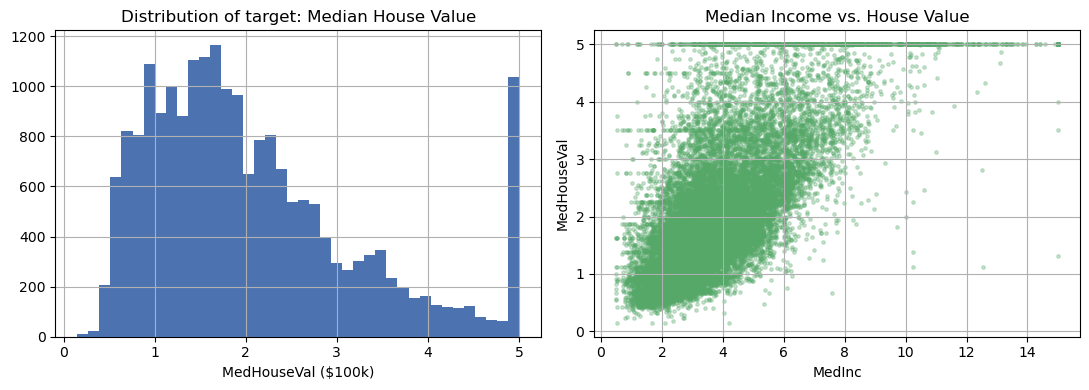

In [3]:
# create one figure with 2 plots side by side (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# LEFT plot: a histogram — how the target values (house prices) are distributed
axes[0].hist(df['MedHouseVal'], bins=40, color='#4C72B0')   # bins=40 controls how many bars
axes[0].set_title('Distribution of target: Median House Value')
axes[0].set_xlabel('MedHouseVal ($100k)')

# RIGHT plot: a scatter plot — does income relate to house value?
# s=6 sets dot size, alpha=0.3 makes dots see-through so overlaps are visible
axes[1].scatter(df['MedInc'], df['MedHouseVal'], s=6, alpha=0.3, color='#55A868')
axes[1].set_title('Median Income vs. House Value')
axes[1].set_xlabel('MedInc')
axes[1].set_ylabel('MedHouseVal')

# tighten up spacing so the two plots don't overlap or look cramped
plt.tight_layout()

# actually render the figure on screen
plt.show()

## 4. Separate features from target — X and y

In [4]:
# X = everything the model is ALLOWED to look at (the inputs).
# .drop(columns=[...]) makes a copy of df with that one column removed
X = df.drop(columns=['MedHouseVal'])

# y = the one column we are trying to predict (the answer key)
y = df['MedHouseVal']

# sanity check: X should have one fewer column than df, and the same number of rows as y
print("X shape:", X.shape, " y shape:", y.shape)

X shape: (20640, 8)  y shape: (20640,)


## 5. The mistake, on purpose — train and score on the *same* data

This is what everyone is tempted to do the first time. Watch the number it produces — then we'll see why it's a lie.

In [5]:
# create a fresh, untrained Linear Regression model
model_wrong = LinearRegression()

# .fit(X, y) is where "learning" happens: the model finds the best-fit line using ALL rows
model_wrong.fit(X, y)

# now ask that SAME model to predict on the SAME rows it just learned from
preds_wrong = model_wrong.predict(X)

# RMSE = "Root Mean Squared Error" — average prediction error, in the same units as the target
# (smaller is better; 0 would mean perfect predictions)
rmse_wrong = np.sqrt(mean_squared_error(y, preds_wrong))

# R^2 = "R-squared" — fraction of the variation in y that the model explains
# (1.0 is perfect, 0.0 means "no better than just guessing the average")
r2_wrong = r2_score(y, preds_wrong)

print("Scored on the training data itself:")
print(f"  RMSE = {rmse_wrong:.3f}")   # :.3f = print with 3 decimal places
print(f"  R^2  = {r2_wrong:.3f}")

Scored on the training data itself:
  RMSE = 0.724
  R^2  = 0.606


This number is **flattering** — the model has already seen every row it is being tested on. It measures memory, not learning. Let's do it properly.

## 6. The correct workflow — `train_test_split`

In [6]:
# randomly split X and y into a TRAIN portion and a TEST portion, together (rows stay matched).
# test_size=0.2  -> 20% of rows go to test, 80% stay for training
# random_state=42 -> makes the "random" split repeatable (same split every time we run this)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# confirm the split sizes look right
print("Train rows:", X_train.shape[0], " Test rows:", X_test.shape[0])

Train rows: 16512  Test rows: 4128


In [8]:
# create a brand new, untrained model (separate from model_wrong above)
model = LinearRegression()

# this time, learn ONLY from the training rows — the test rows stay completely unseen
model.fit(X_train, y_train)

# ask the trained model to predict on the rows it WAS trained on...
train_preds = model.predict(X_train)

# ...and separately, on the rows it has NEVER seen
test_preds = model.predict(X_test)

# compute RMSE for both sets, so we can compare them side by side
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

# compute R^2 for both sets too
train_r2 = r2_score(y_train, train_preds)
test_r2 = r2_score(y_test, test_preds)

# print a small table comparing train vs. test performance
# {:<10} left-aligns text in a 10-character-wide column, {:>10} right-aligns numbers
print(f"{'Metric':<10}{'Train':>10}{'Test':>10}")
print(f"{'RMSE':<10}{train_rmse:>10.3f}{test_rmse:>10.3f}")
print(f"{'R^2':<10}{train_r2:>10.3f}{test_r2:>10.3f}")

Metric         Train      Test
RMSE           0.720     0.746
R^2            0.613     0.576


## 7. The gap is the point

Train performance is always a little better — the model has seen those rows. A **small** gap between train and test is healthy. A **large** gap is the warning sign (overfitting) we will chase for the rest of the course.

In [8]:
# make a square figure so the plot isn't stretched
plt.figure(figsize=(5.5, 5.5))

# scatter plot: for each test house, actual price (x-axis) vs. our prediction (y-axis)
# s=10 -> dot size, alpha=0.35 -> see-through dots so crowded areas are visible
plt.scatter(y_test, test_preds, s=10, alpha=0.35, color='#C44E52')

# a "perfect prediction" reference line: if actual == predicted, the dot sits exactly on this line
lims = [0, 5.2]
plt.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')  # 'k--' = black dashed line

plt.xlabel('Actual MedHouseVal')
plt.ylabel('Predicted MedHouseVal')
plt.title('Predicted vs. Actual (test set)')
plt.legend()          # show the "Perfect prediction" label box
plt.tight_layout()
plt.show()

NameError: name 'test_preds' is not defined

<Figure size 550x550 with 0 Axes>

## 8. 🔧 Try it yourself

Edit the cell below and re-run:

1. Change `test_size` to `0.5`. What happens to the train/test gap?
2. Set `random_state` to a different number. Does the story change much?
3. Drop a feature you think matters least (e.g. `AveBedrms`) from `X` before splitting — do the scores move?

In [10]:
# 🔧 Your turn — edit the values below and re-run this cell

test_size = 0.2       # fraction of rows held out for testing — try 0.5
random_state = 42     # "seed" for the random split — try a different number, e.g. 7

# re-split the data using the values you just set above
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=test_size, random_state=random_state
)

# train a fresh model on the new split
model2 = LinearRegression().fit(X_train2, y_train2)

# print just the test R^2 so it's easy to compare across your experiments
print("Test R^2:", r2_score(y_test2, model2.predict(X_test2)))

Test R^2: 0.5757877060324508


## 9. Check yourself — five questions

Answer these in your own words (no code needed) before next session:

1. What separates supervised from unsupervised learning?
2. Give one regression and one classification example.
3. Why do we split data into train and test?
4. What is the difference between training error and true error?
5. Why can't we just report training accuracy?

## Recap

**Three you learned:** supervised vs. unsupervised · the end-to-end pipeline · training error ≠ true error.

**Two to remember:** the golden rule of the test set · framing decides the model.

**One to ponder:** if more data always shrinks the train–test gap, is there ever a reason *not* to collect more? We answer this in Session 6.